#**Fraud Detection**

##**Objective**
Build a machine learning pipeline to detect fraudulent financial transactions from a heavily imbalanced dataset, addressing class imbalance as a core challenge.


###**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

###**Load the Dataset**

In [ ]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (284807, 31)

Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


###**Initial Dataset Inspection**

In [ ]:
print("Missing Values:")
print(df.isnull().sum().sum())

Missing Values:
0


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 1081


In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


###**Analyzing Class Imbalance**

In [ ]:
class_counts = df["Class"].value_counts()

print("Legitimate Transactions:", class_counts[0])
print("Fraudulent Transactions:", class_counts[1])

fraud_percentage = (class_counts[1] / len(df)) * 100

print(f"Fraudulent Transactions Percentage: {fraud_percentage:.3f}%")

Legitimate Transactions: 284315
Fraudulent Transactions: 492
Fraudulent Transactions Percentage: 0.173%


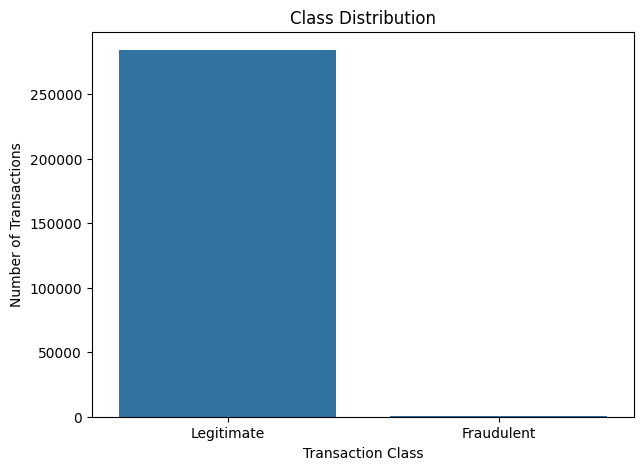

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(x="Class", data=df)

plt.title("Class Distribution")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraudulent"])

plt.show()

The dataset is highly imbalanced. Only approximately 0.173% of all transactions are fraudulent, while the remaining transactions are legitimate. This severe imbalance makes fraud detection challenging because a model could achieve very high accuracy by predicting almost every transaction as legitimate while still failing to identify fraudulent transactions.

###**EDA: Transaction Amount**

In [ ]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


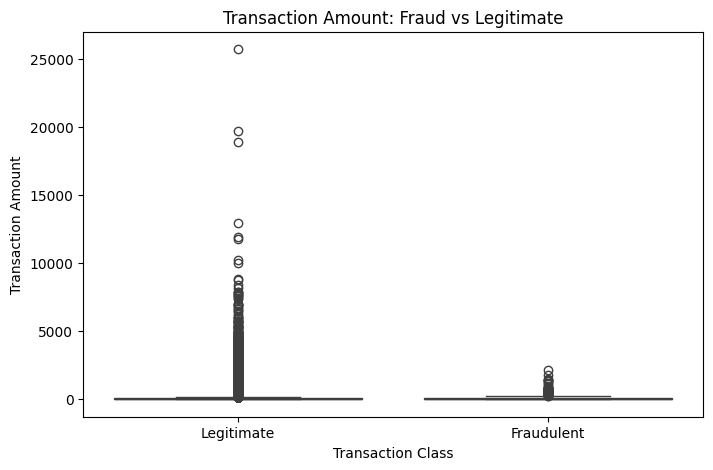

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="Class", y="Amount", data=df)

plt.title("Transaction Amount: Fraud vs Legitimate")
plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")
plt.xticks([0, 1], ["Legitimate", "Fraudulent"])

plt.show()

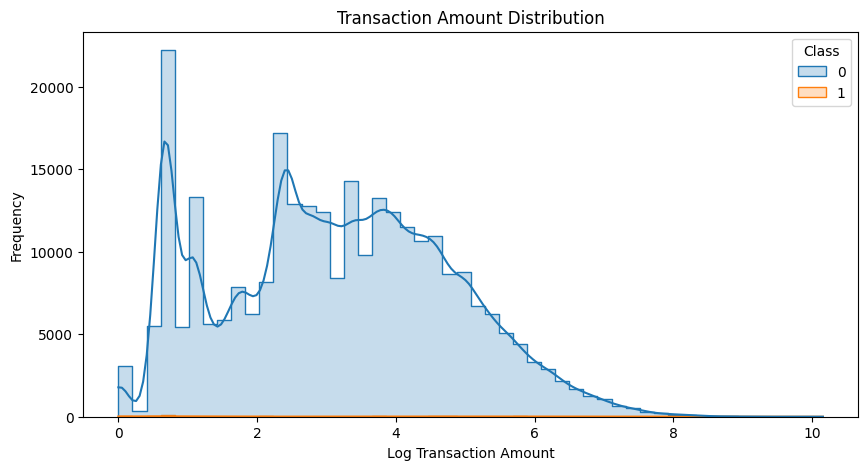

In [ ]:
df["Log_Amount"] = np.log1p(df["Amount"])

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Log_Amount",
    hue="Class",
    bins=50,
    kde=True,
    element="step"
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Log Transaction Amount")
plt.ylabel("Frequency")

plt.show()

###**EDA: Time-of-Day Analysis**

In [ ]:
df["Hour"] = (df["Time"] // 3600) % 24

In [ ]:
fraud_by_hour = df.groupby("Hour")["Class"].mean() * 100

print(fraud_by_hour)

Hour
0.0     0.077973
1.0     0.236967
2.0     1.712740
3.0     0.486827
4.0     1.041195
5.0     0.367893
6.0     0.219459
7.0     0.317548
8.0     0.087583
9.0     0.101023
10.0    0.048199
11.0    0.314428
12.0    0.110246
13.0    0.110641
14.0    0.138805
15.0    0.157949
16.0    0.133714
17.0    0.179389
18.0    0.193673
19.0    0.121414
20.0    0.107424
21.0    0.090380
22.0    0.058286
23.0    0.191991
Name: Class, dtype: float64


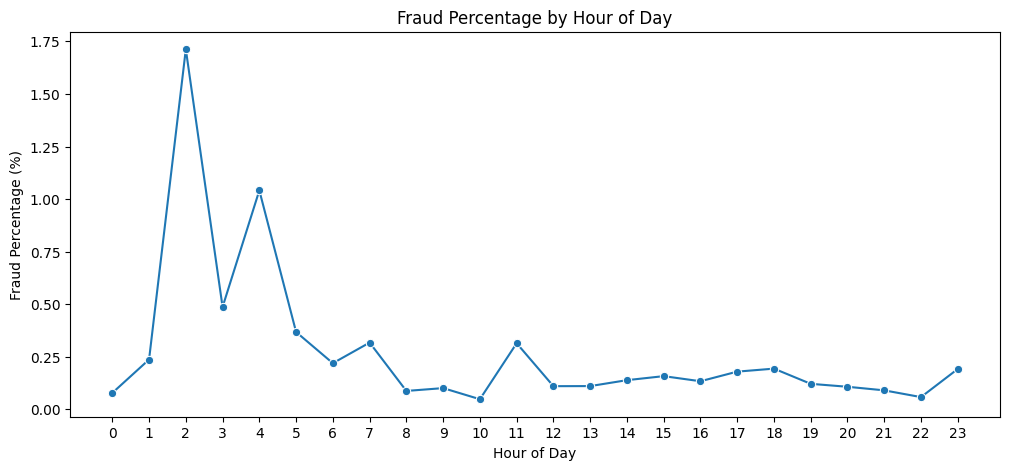

In [ ]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    x=fraud_by_hour.index,
    y=fraud_by_hour.values,
    marker="o"
)

plt.title("Fraud Percentage by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Percentage (%)")
plt.xticks(range(24))

plt.show()

Accuracy is misleading for this dataset because fraudulent transactions represent only about 0.173% of all transactions. A model that predicts every transaction as legitimate would achieve approximately 99.8% accuracy, while detecting zero fraudulent transactions. Therefore, accuracy alone does not measure how effectively the model identifies fraud. Precision, Recall, F1-score, and ROC-AUC are more informative metrics for this problem.

###**Preparing the Data**

In [ ]:
X = df.drop(columns=["Class", "Hour", "Log_Amount"])
y = df["Class"]

###**Train/Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training Set:")
print(y_train.value_counts())

print("\nTesting Set:")
print(y_test.value_counts())

Training Set:
Class
0    227451
1       394
Name: count, dtype: int64

Testing Set:
Class
0    56864
1       98
Name: count, dtype: int64


###**Scale the Features**

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (227845, 30)
Testing data shape: (56962, 30)


###**Apply SMOTE**

In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [ ]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


###**Train Logistic Regression**

In [ ]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_lr = logistic_model.predict(X_test_scaled)
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

###**Train Random Forest**

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Random Forest training completed.")

Random Forest training completed.


In [ ]:
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

###**Evaluate Both Models**

In [ ]:
def evaluate_model(model_name, y_true, y_pred, y_prob):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    print(f"\n{model_name}")
    print("-" * 40)
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

In [ ]:
evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr,
    y_prob_lr
)

evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)


Logistic Regression
----------------------------------------
Precision: 0.0578
Recall:    0.9184
F1-Score:  0.1088
ROC-AUC:   0.9708

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


Random Forest
----------------------------------------
Precision: 0.8667
Recall:    0.7959
F1-Score:  0.8298
ROC-AUC:   0.9551

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.80      0.83        98

    accuracy                           1.00     56962
   macro avg       0.93      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962



###**Confusion Matrix**

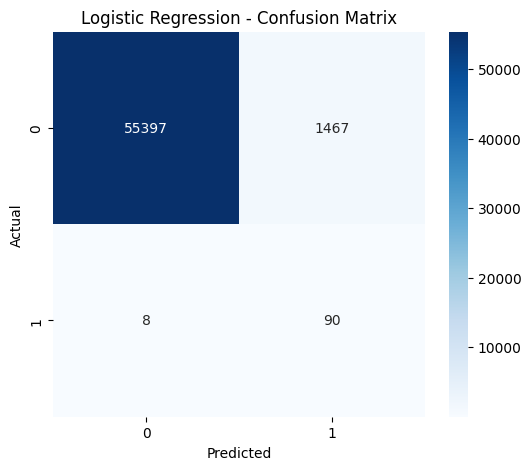

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

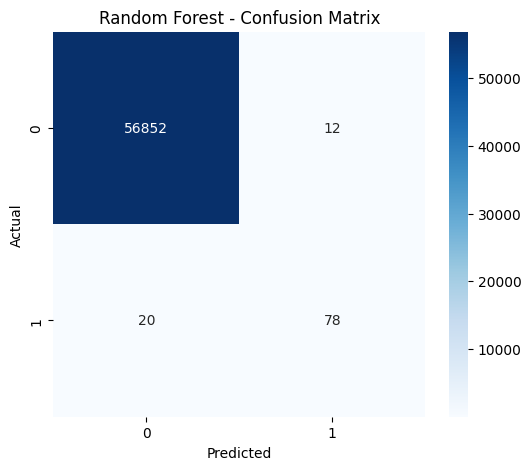

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

###**AUC-ROC Curve**

In [ ]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)

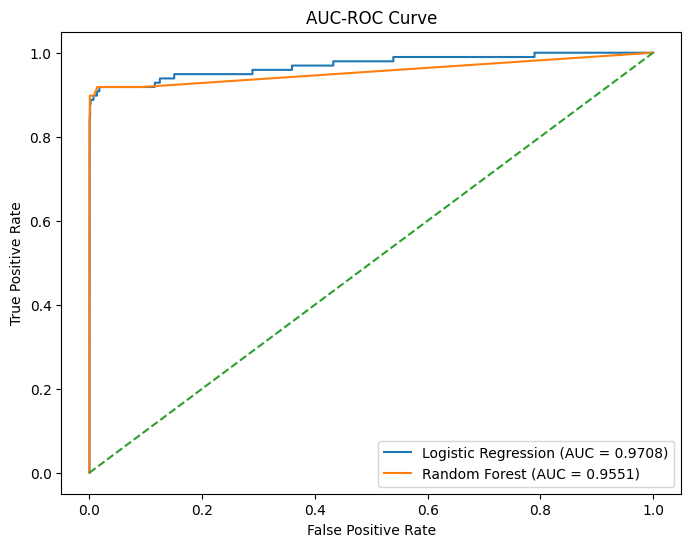

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {auc_lr:.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve")
plt.legend()

plt.show()

###**Comparing the Models**

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.057803,0.918367,0.108761,0.970843
1,Random Forest,0.866667,0.795918,0.829787,0.955123


###**Feature Importance**

In [ ]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

In [ ]:
feature_importance.head(10)

,0
V14,0.283315
V4,0.102001
V10,0.094962
V17,0.082071
V3,0.077402
V12,0.069180
V16,0.049960
V2,0.024926
V9,0.022995
V7,0.021687


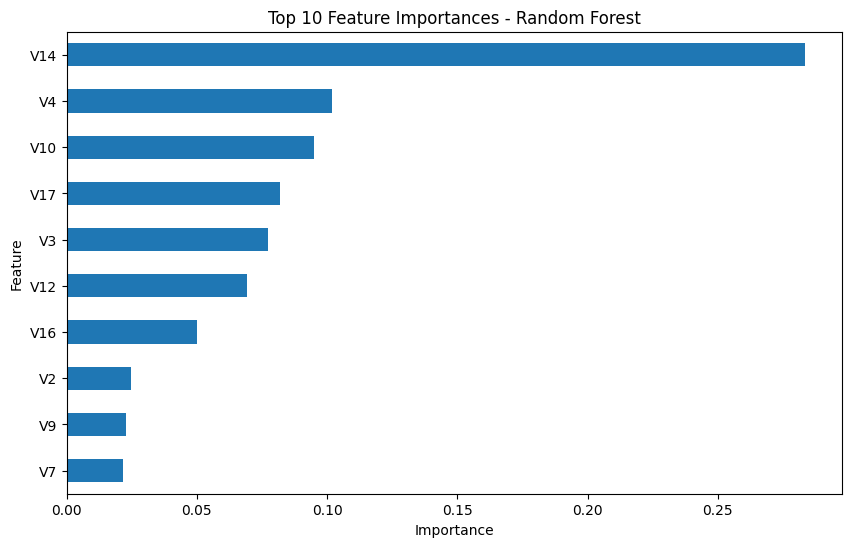

In [ ]:
plt.figure(figsize=(10, 6))

feature_importance.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

###**Explain Recall vs Precision**

Recall is particularly important in fraud detection because it measures the proportion of actual fraudulent transactions that the model successfully identifies. A low recall means many fraudulent transactions are missed.

However, maximizing recall can increase false positives, meaning legitimate transactions may be incorrectly flagged as fraud. Precision measures how many transactions flagged as fraudulent are actually fraudulent.

Therefore, the appropriate balance depends on the business situation. For a system where missing fraud is extremely costly, higher recall may be prioritized. For a system where incorrectly blocking legitimate customers is costly, precision becomes more important. F1-score can be used when a balance between precision and recall is desired.

## **Conclusion**

This project involved training a machine learning model to detect credit card fraudulent financial transactions. A credit card transaction financial dataset was used with 284,807 rows (observations) and 31 columns (variables). There were 492 fraudulent transactions in the dataset, which is about 0.173%.

An initial Exploratory Data Analysis was performed to determine the class distribution, analyze the amount of money distribution, and time of fraudulent financial transactions occurrence. It was found that Accuracy is not a good metric to evaluate the model’s performance, due to the huge difference between classes.

The SMOTE algorithm was used to balance the dataset, but only on the train set. Stratified splitting was used to split the data into train and test sets to maintain the proportion of fraudulent financial transactions in both sets.

A machine learning model was trained on the imbalanced dataset using the Logistic Regression algorithm and Random Forest algorithm. Model performance was evaluated using classification metrics: Precision, Recall, F1-Score, and ROC-AUC. Using the model to predict fraudulent financial transactions, one should be especially concerned about Recall. Even if the model incorrectly labels some legitimate transactions as fraudulent, it should not label any fraudulent transactions as legitimate.

The importance of features was analyzed using the Random Forest classifier. Due to the nature of the problem, the column names have been encoded using the Principal Component Analysis (PCA). Thus, the interpretation of feature importance does not relate to actual features but to encoded variables.

At last, a system that could process a million transactions per hour was designed. Such systems need to have efficient data pre-processing and use a trained model that can perform predictions fast enough to keep up with a million transactions per hour. Moreover, there should be a separate system for monitoring and updating the model to handle new fraud patterns.

In conclusion, a complete machine learning workflow was demonstrated on a credit card transaction dataset. The task of distinguishing between legitimate and fraudulent financial transactions was a typical example of a binary classification task with an imbalanced dataset. Initially, there was a huge difference between the number of legitimate and fraudulent transactions in the dataset. The dataset was balanced using the SMOTE algorithm, and stratified splitting was used to split the data into train and test sets. Finally, a machine learning model was trained and evaluated using different classification performance metrics and compared using feature importance analysis.